In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

# **a. Load Dataset 'wisconsin_data-02.csv't**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/wisconsin_data-02.csv')
df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


# **b. Insert a validation data at the end of the dataframe**

In [ ]:
data = [[2.68, 23.84, 82.69, 499, 0.1122, 0.1262, 0.1128, 0.06873, 0.1905, 0.0659, 0.4255, 1.178, 2.927, 36.46, 0.007781, 0.02648, 0.02973, 0.0129, 0.01635, 0.003601, 17.09, 33.47, 111.8, 888.3, 0.1851, 0.4061, 0.4024, 0.1716, 0.3383, 0.103, 'Unknown'], [3.08, 15.71, 85.63, 520, 0.1075, 0.127, 0.04568, 0.0311, 0.1967, 0.06811, 0.1852, 0.7477, 1.383, 14.67, 0.004097, 0.01898, 0.01698, 0.00649, 0.01678,0.002425, 14.5, 20.49,	96.09, 630.5, 0.1312, 0.2776, 0.189, 0.07283, 0.3184, 0.0818, 'Unknown']]
validation_df = pd.DataFrame(data, columns=df.columns)
df = pd.concat([df, validation_df], ignore_index=True)
df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.26540,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.18600,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.24300,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.25750,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.16250,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400,M
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039,B
569,2.68,23.84,82.69,499.0,0.11220,0.12620,0.11280,0.06873,0.1905,0.06590,...,33.47,111.80,888.3,0.18510,0.40610,0.4024,0.17160,0.3383,0.10300,Unknown


In [ ]:
# Use StandardScaler to normalize the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns_to_scale = df.columns[:-1]
df_to_scale = df[columns_to_scale]

# Fit the scaler to the selected columns and transform the data
df_scaled_values = scaler.fit_transform(df_to_scale)

# Convert the scaled data back to a pandas DataFrame with appropriate column names
df_scaled_df = pd.DataFrame(df_scaled_values, columns=columns_to_scale)

# Add the target column back to the scaled DataFrame
df_scaled_df[df.columns[-1]] = df[df.columns[-1]]

# Display the scaled dataset
df_scaled_df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.090869,-2.074066,1.273053,0.987257,1.565251,3.286776,2.657057,2.535780,2.218964,2.256113,...,-1.359651,2.307731,2.005159,1.299935,2.617114,2.111815,2.297366,2.751308,1.936854,M
1,1.812132,-0.354085,1.689727,1.912935,-0.830403,-0.489255,-0.023459,0.548789,-0.000198,-0.871690,...,-0.369842,1.537994,1.894235,-0.378466,-0.432793,-0.147331,1.087481,-0.246314,0.279763,M
2,1.566120,0.455865,1.570088,1.562602,0.938936,1.052966,1.365833,2.039871,0.939381,-0.400533,...,-0.024710,1.350035,1.459342,0.521926,1.081973,0.855666,1.956038,1.151280,0.199903,M
3,-0.745835,0.253378,-0.592488,-0.764125,3.280499,3.406342,1.919035,1.453563,2.869724,4.914177,...,0.133203,-0.250003,-0.550146,3.380453,3.895019,1.991725,2.176987,6.050149,4.937143,M
4,1.733856,-1.152399,1.780487,1.830336,0.277035,0.538639,1.373377,1.430317,-0.011166,-0.565154,...,-1.467098,1.341084,1.223408,0.215968,-0.315636,0.613564,0.729392,-0.871426,-0.399046,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,0.702282,2.045509,0.674859,0.580244,-0.843926,-0.040215,0.047075,0.105829,-0.811820,-0.898654,...,1.373722,0.580298,0.429332,-0.811179,0.349104,0.326787,0.413968,-1.107867,-0.320295,M
567,1.820519,2.336440,1.986761,1.739192,1.522548,3.275388,3.302041,2.662339,2.138533,1.042741,...,2.236549,2.307731,1.656540,1.422318,3.906480,3.201278,2.291270,1.918905,2.219691,M
568,-1.769022,1.221594,-1.816105,-1.348299,-3.115740,-1.153894,-1.116033,-1.263601,-0.822788,-0.563735,...,0.763230,-1.434742,-1.076772,-1.857557,-1.210615,-1.307888,-1.746758,-0.050359,-0.753423,B
569,-3.189184,1.058673,-0.381676,-0.442559,1.123984,0.413379,0.302176,0.511596,0.339805,0.438184,...,1.267903,0.135760,0.014334,2.300857,0.964816,0.625092,0.868056,0.778805,1.055069,Unknown


# **c. Remove the validation data from the dataset before training**

In [ ]:
df_scaled_df = df_scaled_df[:-2]
df_scaled_df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.090869,-2.074066,1.273053,0.987257,1.565251,3.286776,2.657057,2.535780,2.218964,2.256113,...,-1.359651,2.307731,2.005159,1.299935,2.617114,2.111815,2.297366,2.751308,1.936854,M
1,1.812132,-0.354085,1.689727,1.912935,-0.830403,-0.489255,-0.023459,0.548789,-0.000198,-0.871690,...,-0.369842,1.537994,1.894235,-0.378466,-0.432793,-0.147331,1.087481,-0.246314,0.279763,M
2,1.566120,0.455865,1.570088,1.562602,0.938936,1.052966,1.365833,2.039871,0.939381,-0.400533,...,-0.024710,1.350035,1.459342,0.521926,1.081973,0.855666,1.956038,1.151280,0.199903,M
3,-0.745835,0.253378,-0.592488,-0.764125,3.280499,3.406342,1.919035,1.453563,2.869724,4.914177,...,0.133203,-0.250003,-0.550146,3.380453,3.895019,1.991725,2.176987,6.050149,4.937143,M
4,1.733856,-1.152399,1.780487,1.830336,0.277035,0.538639,1.373377,1.430317,-0.011166,-0.565154,...,-1.467098,1.341084,1.223408,0.215968,-0.315636,0.613564,0.729392,-0.871426,-0.399046,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.088896,0.721194,2.065145,2.348716,1.038577,0.217897,1.950467,2.323985,-0.314610,-0.934133,...,0.116924,1.755788,2.019244,0.373318,-0.275522,0.664962,1.629948,-1.363742,-0.711275,M
565,1.689126,2.085076,1.619594,1.727799,0.099105,-0.019338,0.694447,1.265273,-0.219556,-1.061856,...,2.046076,1.424622,1.498077,-0.693166,-0.397136,0.236479,0.733963,-0.534578,-0.976365,M
566,0.702282,2.045509,0.674859,0.580244,-0.843926,-0.040215,0.047075,0.105829,-0.811820,-0.898654,...,1.373722,0.580298,0.429332,-0.811179,0.349104,0.326787,0.413968,-1.107867,-0.320295,M
567,1.820519,2.336440,1.986761,1.739192,1.522548,3.275388,3.302041,2.662339,2.138533,1.042741,...,2.236549,2.307731,1.656540,1.422318,3.906480,3.201278,2.291270,1.918905,2.219691,M


# **d. Train/Test Split is test_size = 0.2, random_state = 101**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X2 = df_scaled_df.drop('diagnosis', axis = 1)
y2 = df_scaled_df['diagnosis']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=101)

X2_test

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
107,-0.483050,-0.174872,-0.533494,-0.534557,-0.828268,-0.688343,-0.783735,-0.767434,-0.767948,-0.305450,...,-0.617588,0.294373,-0.647104,-0.591699,-0.614491,-0.371031,-0.377425,-0.460379,0.131020,-0.672455
437,-0.013390,-0.770698,-0.089180,-0.122987,-0.841791,-0.862948,-0.671711,-0.503208,-0.358482,-0.543867,...,-0.126011,-0.667761,-0.180488,-0.229170,-0.566412,-0.823741,-0.771323,-0.611081,-0.286801,-0.645280
195,-0.329292,-0.689237,-0.388277,-0.393000,-1.209750,-0.963346,-0.629089,-0.649656,0.061953,-0.871690,...,-0.495213,-0.599386,-0.490471,-0.492219,-0.994754,-0.662013,-0.460528,-0.491921,0.197418,-0.803336
141,0.565298,-0.288917,0.542844,0.451788,0.057113,0.176144,0.071717,0.271390,0.178943,-0.047165,...,0.757583,-0.067038,0.648918,0.621248,-0.046283,-0.197205,0.038089,0.106164,-0.178297,-0.132846
319,-0.463480,-0.533299,-0.550408,-0.504366,-1.483051,-1.326221,-0.947306,-0.824774,-1.243222,-1.022120,...,-0.698481,-0.890794,-0.760476,-0.641350,-2.114125,-1.320895,-1.200431,-1.315222,-1.621236,-1.367346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,-0.153170,-1.147744,-0.184891,-0.250873,0.098393,-0.438961,-0.278183,-0.028738,0.266686,-0.731194,...,-0.240091,-1.045452,-0.225240,-0.297486,0.504443,-0.492008,-0.159821,0.215876,0.121304,-0.631415
313,-0.712288,-1.994933,-0.751319,-0.698616,-0.742861,-0.848904,-0.944163,-1.033546,0.076577,-0.257199,...,-0.814634,-2.085729,-0.776288,-0.726040,-1.016608,-0.585607,-0.908034,-1.028293,0.790141,-0.534364
139,-0.784974,-1.373506,-0.781435,-0.767828,1.422907,0.174246,-0.533285,-0.024863,-0.150093,-0.296935,...,-0.901749,-1.613616,-0.916512,-0.785552,0.185372,-0.460809,-0.891461,-0.434627,-1.295724,-0.894842
495,0.218644,0.213811,0.172376,0.075536,-0.038257,-0.397966,-0.258067,0.015171,-1.188383,-0.756739,...,-0.053416,0.455543,-0.099934,-0.170011,-0.474625,-0.737147,-0.491271,-0.197069,-0.863328,-0.997440


In [ ]:
y2_train

,diagnosis
476,B
130,B
246,B
205,M
16,M
...,...
552,B
393,M
75,M
337,M


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn_model.fit(X2_train, y2_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn_predictions = knn_model.predict(X2_test)
knn_predictions

array(['B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M', 'M',
       'M', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B',
       'B', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M',
       'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B',
       'M', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M'], dtype=object)

# **Proving of answers (6-10)**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

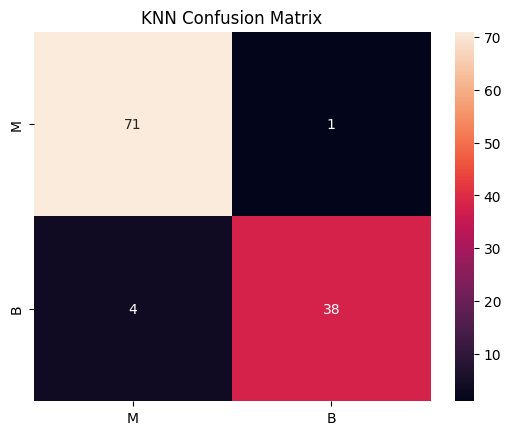

In [ ]:
# Confusion Matrix

knn_cm = confusion_matrix(y2_test, knn_predictions)
sns.heatmap(knn_cm, annot = True, fmt = 'd', xticklabels = ['M', 'B'], yticklabels = ['M', 'B']).set(title = 'KNN Confusion Matrix')
plt.show()

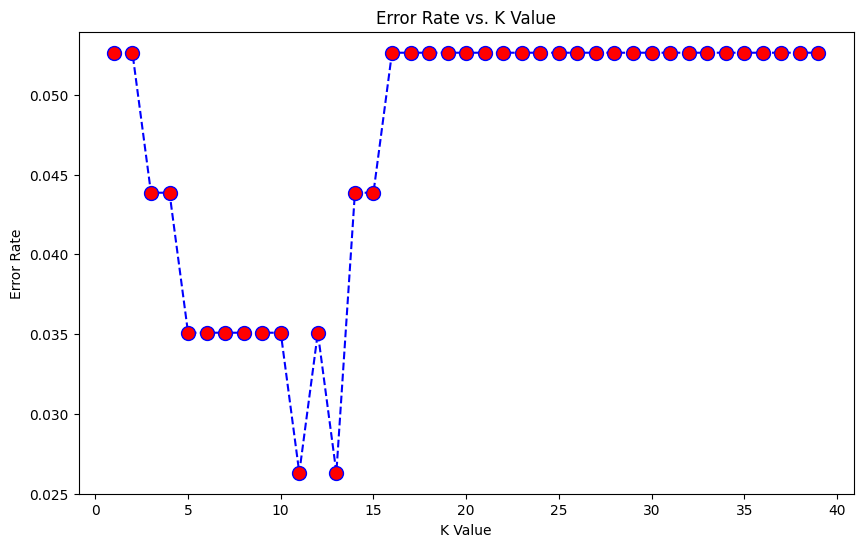

The optimized k-value is: 11


In [ ]:
error_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X2_train, y2_train)
    pred_i = knn.predict(X2_test)
    error_rate.append(np.mean(pred_i != y2_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()

# Find the optimal k value
optimal_k = error_rate.index(min(error_rate)) + 1
print(f"The optimized k-value is: {optimal_k}")


In [ ]:
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X2_train, y2_train)
knn_optimal_predictions = knn_optimal.predict(X2_test)

# Calculate accuracy
accuracy = (knn_optimal_predictions == y2_test).mean()
print(f"The accuracy of the model with optimized k-value is: {accuracy:.4f}")

# Display classification report for more detailed metrics
print("\nClassification Report:")
print(classification_report(y2_test, knn_optimal_predictions))

The accuracy of the model with optimized k-value is: 0.9737

Classification Report:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        72
           M       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
tp = knn_cm[0, 0]

print("True Positive (TP):", tp)

True Positive (TP): 71


In [ ]:
# Predict for the validation data
validation_data = df_scaled_df.tail(2).drop('diagnosis', axis=1) # Get the last two rows as validation data
validation_predictions = knn_model.predict(validation_data)

# Print the prediction for validation data number 1 (which is the first of the two validation rows)
print(f"Prediction for 1st validation data: {validation_predictions[0]}")

Prediction for 1st validation data: M


In [ ]:
validation_data_row2 = df.iloc[-1:].drop('diagnosis', axis=1)
validation_data_row2_scaled = scaler.transform(validation_data_row2)

# Predict using the trained KNN model
prediction_validation_row2 = knn_model.predict(validation_data_row2_scaled)

print(f"Prediction for 2nd validation data: {prediction_validation_row2[0]}")

Prediction for 2nd validation data: B


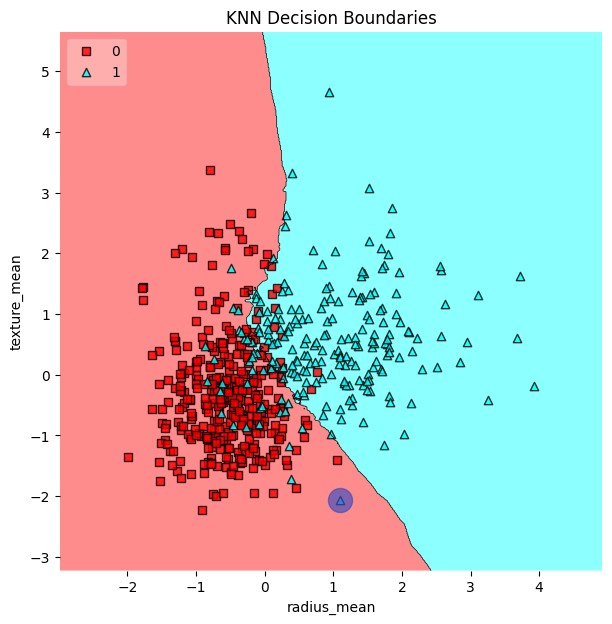

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
from mlxtend.plotting import plot_decision_regions
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

X2 = df_scaled_df.drop('diagnosis', axis = 1)
y = df_scaled_df['diagnosis']

x_label = X2.columns[0]
y_label = X2.columns[1]

sf_x = X2.iloc[0][x_label]
sf_y = X2.iloc[0][y_label]

y_encoded = y.map({'M': 1, 'B': 0})
sp_encoded = y_encoded.iloc[0]

def knn_plots(X2, y_encoded):
    features = X2[[x_label, y_label]].values
    target = y_encoded.values

    new_model = KNeighborsClassifier(n_neighbors=40)
    new_model.fit(features, target)

    plt.figure(figsize=(7, 7))
    plt.title('KNN Decision Boundaries')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plot_decision_regions(features, target, clf=new_model, legend=2, colors='red,cyan')

    plt.scatter(x=sf_x, y=sf_y, c=sp_encoded, marker='o', s=300, alpha=0.65, cmap='coolwarm') # Use a colormap for consistency
    plt.show()

knn_plots(X2, y_encoded)